### 1. Load the Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder #For categorical variables


In [20]:
# 1. Load the Data
excel_file = "Garmin_activities.xlsx"
sheet_name = "Garmin_data"

data = pd.read_excel(excel_file, sheet_name=sheet_name)
data

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Avg Resp,Min Resp,Max Resp,Moving Time,Elapsed Time,Min Elevation,Max Elevation,userID,location,Series totales
0,Gym training,2022-02-06 19:16:03.993,False,Fuerza,0.00,131.0,1899-12-29 00:44:45,99.0,134.0,NaN,...,NaN,NaN,NaN,0.031076,0.031076,NaN,NaN,AMG,FUERZA,--
1,Gym training,2022-02-22 20:36:51.983,False,Fuerza,0.00,116.0,1899-12-29 00:32:37,111.0,134.0,NaN,...,NaN,NaN,NaN,0.022650,0.022650,NaN,NaN,AMG,FUERZA,--
2,Gym training,2022-06-15 11:39:56.016,False,Fuerza,0.00,90.0,1899-12-29 00:34:18,95.0,121.0,NaN,...,NaN,NaN,NaN,0.023819,0.023819,NaN,NaN,AMG,FUERZA,--
3,Indoor Cycling,2022-09-02 10:03:48.036,False,Ciclismo en sala,20.71,350.0,1899-12-29 00:56:26,146.0,177.0,NaN,...,NaN,NaN,NaN,0.039155,0.039190,NaN,NaN,AMG,INDOOR,--
4,Indoor Cycling,2022-09-26 11:09:46.023,False,Ciclismo en sala,17.77,305.0,1899-12-29 00:46:51,151.0,178.0,NaN,...,NaN,NaN,NaN,0.032465,0.035579,NaN,NaN,AMG,INDOOR,--
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,Road Cycling,2022-08-27 07:13:23.980,False,Tenjo Road Cycling,115.11,2277.0,1899-12-29 05:15:36,134.0,184.0,45.0,...,27.0,13.0,40.0,0.218576,0.295498,1663.0,2759.0,AARL,TENJO,NaN
1129,Road Cycling,2022-09-04 06:49:00.970,False,Tenjo Road Cycling,129.91,2995.0,1899-12-29 05:46:22,141.0,181.0,50.0,...,30.0,13.0,42.0,0.240231,0.279259,1185.0,2748.0,AARL,TENJO,NaN
1130,Road Cycling,2022-03-06 08:28:23.003,False,Villeta Road Cycling,81.81,2335.0,1899-12-29 05:41:49,155.0,183.0,50.0,...,34.0,19.0,43.0,0.232662,0.366759,756.0,2823.0,KMP,VILLETA,NaN
1131,Road Cycling,2022-03-06 08:31:53.990,False,Villeta Ciclismo en ruta,105.91,3433.0,1899-12-29 07:12:14,137.0,172.0,50.0,...,26.0,10.0,40.0,0.273171,0.401157,721.0,2787.0,AARL,VILLETA,NaN


### 2. Data Cleaning and Preparation

In [4]:
# Data Cleaning and Preparation (Improved)

# Convert 'Date' to datetime objects
data['Date'] = pd.to_datetime(data['Date'])

# Handle missing values (example: fill with mean for numeric columns)
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].mean(), inplace=True)

# Clean 'Time' column by replacing '####' with NaN and then imputing with a default value
# Check if 'Time' column exists before cleaning
if 'Time' in data.columns:
    data['Time'] = data['Time'].replace('####', pd.NA)
    data['Time'] = data['Time'].fillna('00:00:00')  # Replace NaN with a default time
else:
    print("Warning: 'Time' column not found in the dataset.")

# Drop duplicates
data.drop_duplicates(inplace=True)

C:\Users\Alejandro.rodriguezl\AppData\Local\Temp\ipykernel_9516\3699789760.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [5]:
# Display the first 5 rows
print(data.head())

    Activity Type                    Date  Favorite             Title  \
0    Gym training 2022-02-06 19:16:03.993     False            Fuerza   
1    Gym training 2022-02-22 20:36:51.983     False            Fuerza   
2    Gym training 2022-06-15 11:39:56.016     False            Fuerza   
3  Indoor Cycling 2022-09-02 10:03:48.036     False  Ciclismo en sala   
4  Indoor Cycling 2022-09-26 11:09:46.023     False  Ciclismo en sala   

   Distance  Calories                Time  Avg HR  Max HR  Aerobic TE  ...  \
0      0.00     131.0 1899-12-29 00:44:45    99.0   134.0   33.722603  ...   
1      0.00     116.0 1899-12-29 00:32:37   111.0   134.0   33.722603  ...   
2      0.00      90.0 1899-12-29 00:34:18    95.0   121.0   33.722603  ...   
3     20.71     350.0 1899-12-29 00:56:26   146.0   177.0   33.722603  ...   
4     17.77     305.0 1899-12-29 00:46:51   151.0   178.0   33.722603  ...   

    Avg Resp   Min Resp   Max Resp Moving Time  Elapsed Time  Min Elevation  \
0  28.303293 

In [6]:
# Get information about the columns (data types, missing values)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1131 entries, 0 to 1132
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Activity Type             1131 non-null   object        
 1   Date                      1131 non-null   datetime64[ns]
 2   Favorite                  1131 non-null   bool          
 3   Title                     1131 non-null   object        
 4   Distance                  1131 non-null   float64       
 5   Calories                  1131 non-null   float64       
 6   Time                      1131 non-null   datetime64[ns]
 7   Avg HR                    1131 non-null   float64       
 8   Max HR                    1131 non-null   float64       
 9   Aerobic TE                1131 non-null   float64       
 10  Avg Run Cadence           1131 non-null   int64         
 11  Max Run Cadence           1131 non-null   int64         
 12  Avg Speed                

In [7]:
# Get descriptive statistics for numeric columns
print(data.describe())

                                Date     Distance     Calories  \
count                           1131  1131.000000  1131.000000   
mean   2022-04-18 05:23:39.573535744    31.789452   661.353257   
min       2021-05-28 07:04:21.993000     0.000000     5.000000   
25%    2022-01-29 10:57:03.023000064    10.630000   313.500000   
50%    2022-04-29 17:48:52.043000064    27.230000   552.000000   
75%    2022-08-04 11:52:40.481499904    47.505000   859.500000   
max       2022-10-11 18:21:37.036000   197.310000  4302.000000   
std                              NaN    28.183800   530.994767   

                                Time       Avg HR       Max HR   Aerobic TE  \
count                           1131  1131.000000  1131.000000  1131.000000   
mean   1899-12-29 01:40:09.921573632   132.097536   164.479277    33.724765   
min       1899-12-29 00:00:49.600000     0.000000     0.000000     0.000000   
25%              1899-12-29 00:51:29   122.000000   157.000000    33.000000   
50%       

### 3. Descriptive Analysis and Visualization

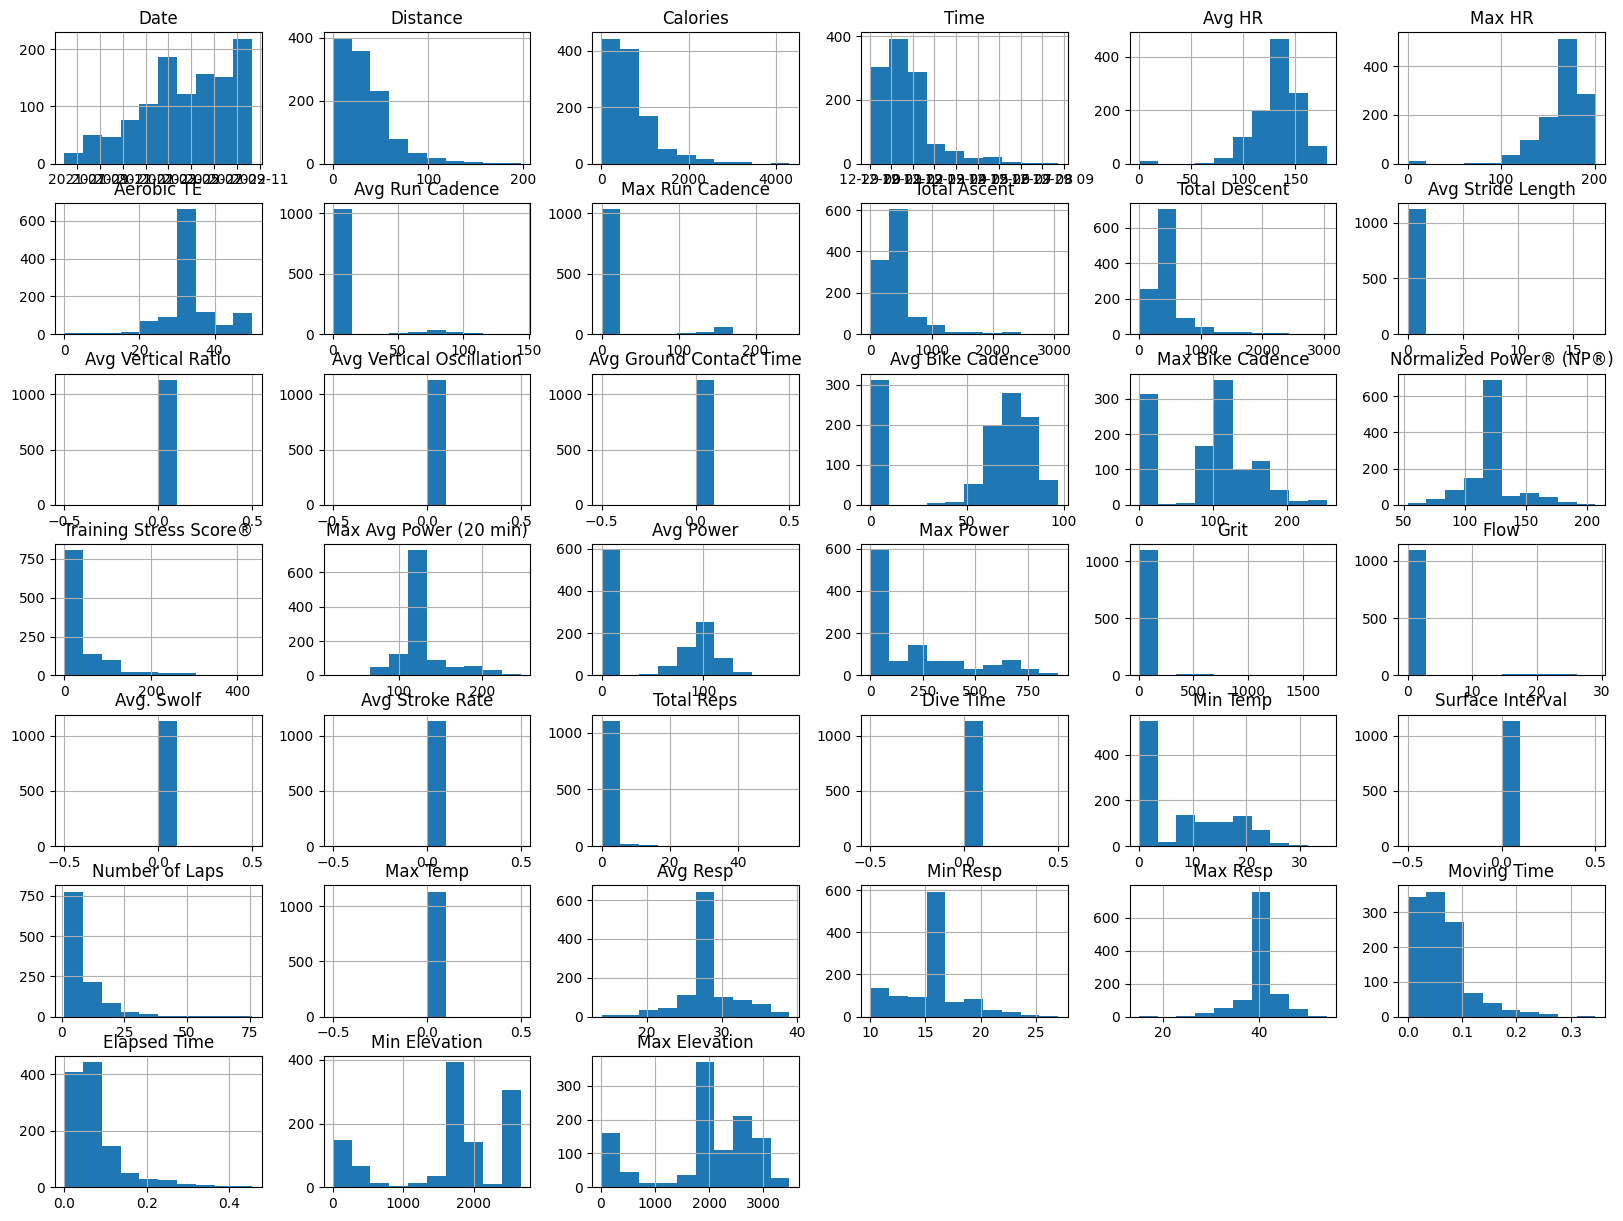

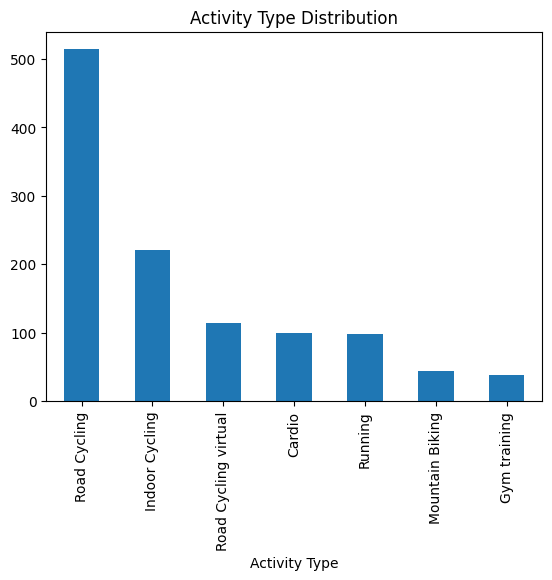

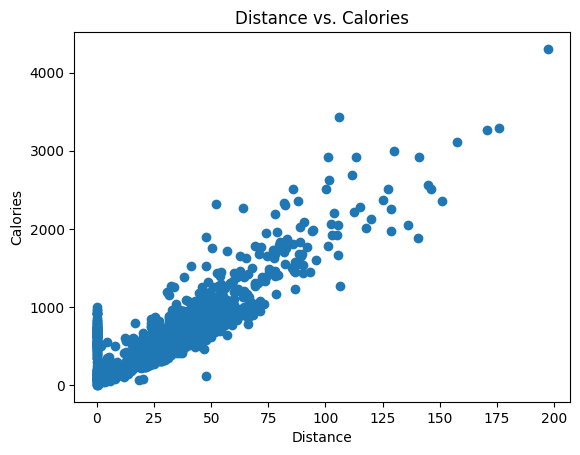

In [9]:
# --- Univariate Analysis ---

# Histograms for numeric variables
data.hist(figsize=(20, 15))
plt.show()

# Bar chart for Activity Type
data['Activity Type'].value_counts().plot(kind='bar')
plt.title('Activity Type Distribution')
plt.show()

# --- Bivariate Analysis ---

# Scatter plot: Distance vs. Calories
plt.scatter(data['Distance'], data['Calories'])
plt.xlabel('Distance')
plt.ylabel('Calories')
plt.title('Distance vs. Calories')
plt.show()



Total Distance and Calories by User:
         Distance      Calories
userID                        
AARL    12995.59  272476.26702
AMG      6404.98  115601.00000
CCO       629.16   17239.26702
JJ       1286.17   91872.00000
KMP     14637.97  250802.00000


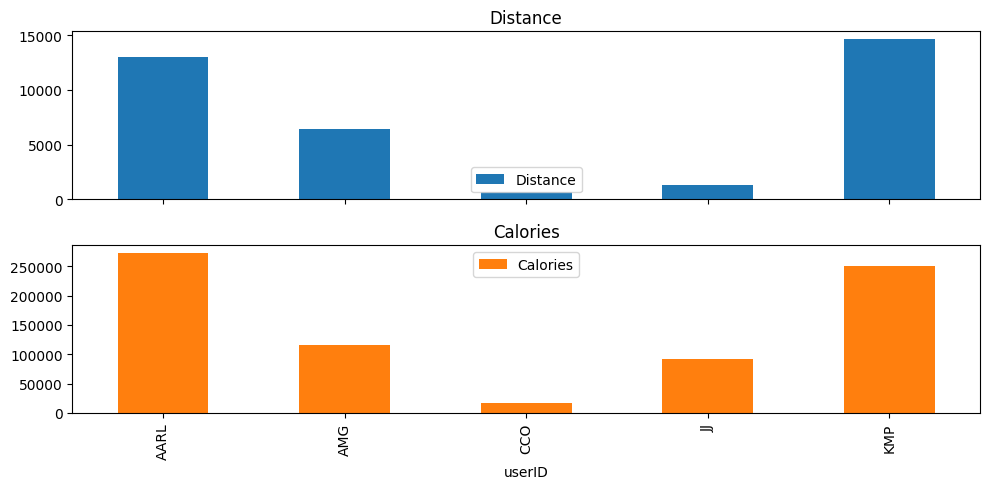


Total Distance and Calories by Activity Type:
                       Distance       Calories
Activity Type                                
Cardio                    0.00   62845.000000
Gym training              0.00    4679.000000
Indoor Cycling         4620.11   82934.000000
Mountain Biking        1706.13   41489.000000
Road Cycling          26646.55  509320.534041
Road Cycling virtual   2809.40   36712.000000
Running                 171.68   10011.000000


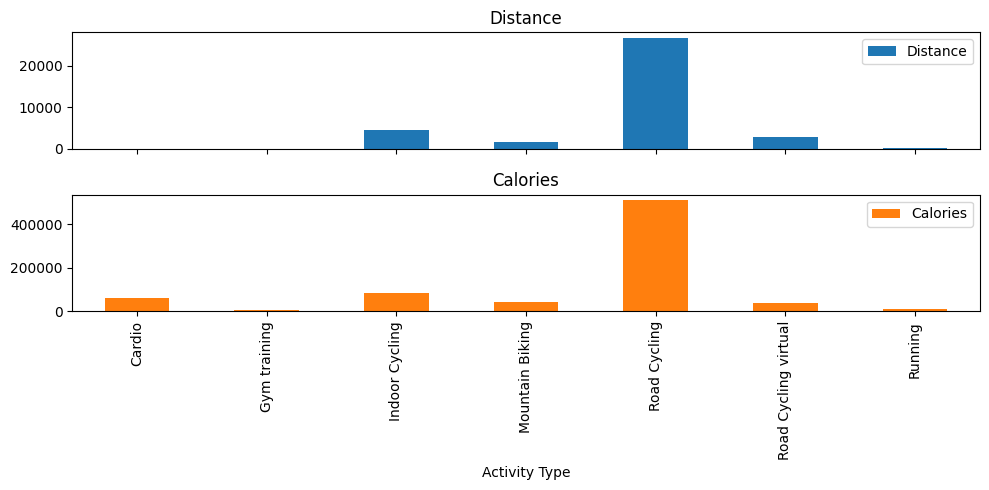

In [10]:
# --- Totalizations ---

# Total distance and calories by user
user_totals = data.groupby('userID').agg({'Distance': 'sum', 'Calories': 'sum'})
print("\nTotal Distance and Calories by User:\n", user_totals)

user_totals.plot(kind='bar', subplots=True, figsize=(10, 5))
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

# Total distance and calories by activity type
activity_totals = data.groupby('Activity Type').agg({'Distance': 'sum', 'Calories': 'sum'})
print("\nTotal Distance and Calories by Activity Type:\n", activity_totals)

activity_totals.plot(kind='bar', subplots=True, figsize=(10, 5))
plt.tight_layout()
plt.show()


Correlation Matrix:
                           Distance  Calories    Avg HR    Max HR  Aerobic TE  \
Distance                  1.000000  0.868272  0.284557  0.354269    0.559156   
Calories                  0.868272  1.000000  0.285099  0.384750    0.637193   
Avg HR                    0.284557  0.285099  1.000000  0.891537    0.684095   
Max HR                    0.354269  0.384750  0.891537  1.000000    0.653065   
Aerobic TE                0.559156  0.637193  0.684095  0.653065    1.000000   
Avg Run Cadence          -0.317427 -0.315547 -0.348432 -0.396528         NaN   
Max Run Cadence          -0.322980 -0.317347 -0.380127 -0.409144         NaN   
Total Ascent              0.724331  0.872463  0.358042  0.380812    0.601314   
Total Descent             0.715893  0.804198  0.321222  0.365129    0.542835   
Avg Stride Length        -0.190328 -0.188400 -0.221753 -0.221812         NaN   
Avg Vertical Ratio             NaN       NaN       NaN       NaN         NaN   
Avg Vertical Oscil

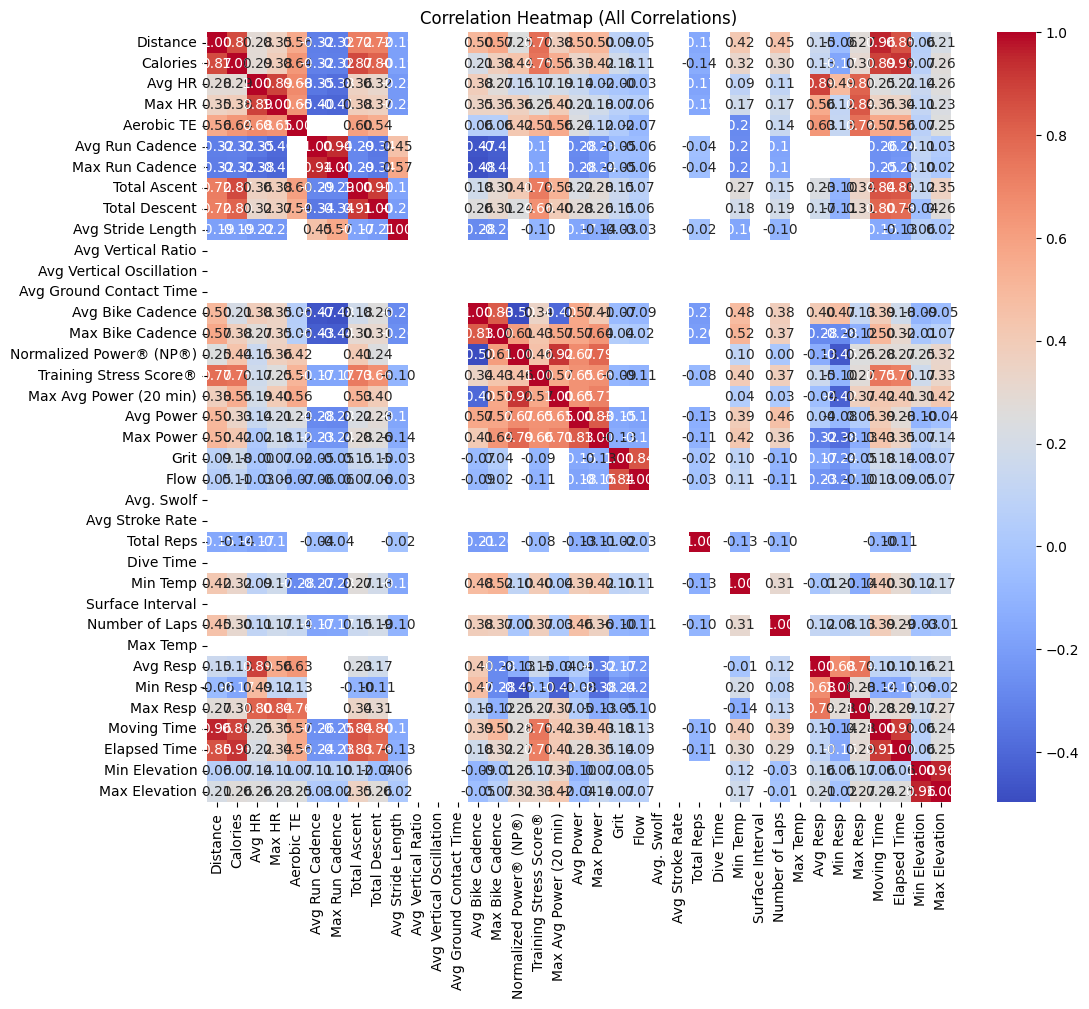

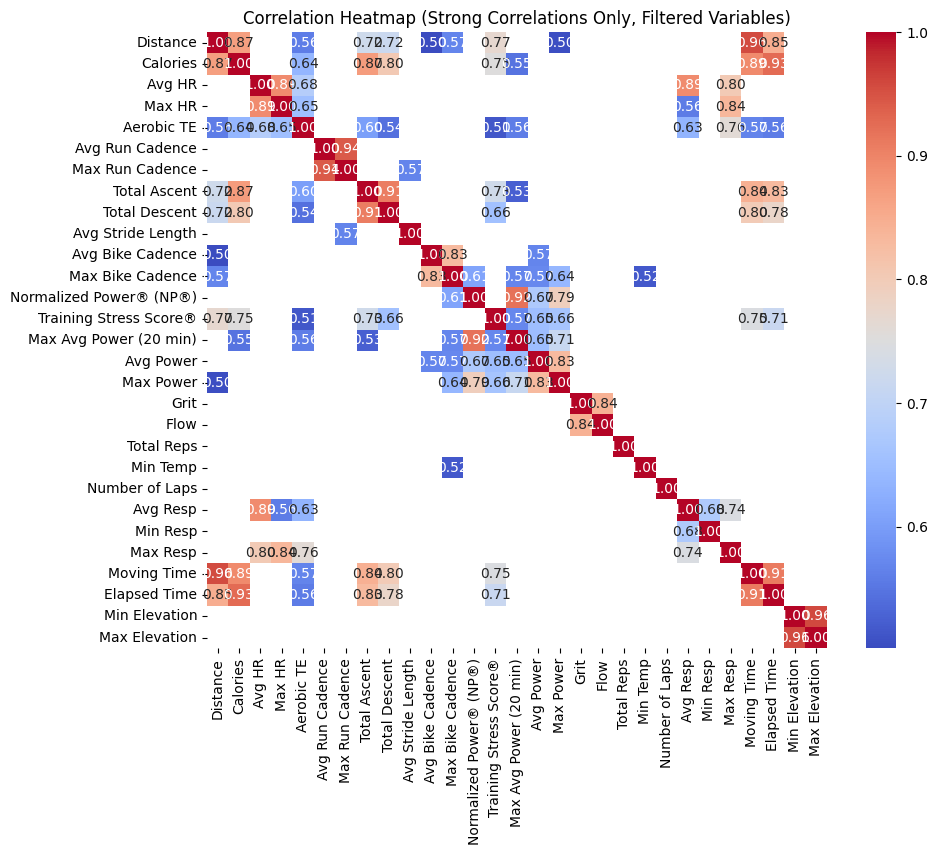

In [16]:
# --- Correlations ---

# Correlation matrix (for numeric columns)
numeric_data = data.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)

# Heatmap of the correlation matrix (original)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (All Correlations)')
plt.show()

# Heatmap of strong correlations (>= 0.5 or <= -0.5) with variable filtering
strong_correlations = correlation_matrix[
    (correlation_matrix >= 0.5) | (correlation_matrix <= -0.5)
]

# Identify variables with at least one strong correlation
strong_vars = strong_correlations.columns[strong_correlations.notna().any()]

# Filter the strong correlations matrix to include only these variables
strong_correlations_filtered = strong_correlations.loc[strong_vars, strong_vars]

# Create a mask to hide the weak correlations (which should all be hidden now)
mask = strong_correlations_filtered.isnull()

plt.figure(figsize=(10, 8))  # Adjust figure size for better viewing
sns.heatmap(strong_correlations_filtered, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Heatmap (Strong Correlations Only, Filtered Variables)')
plt.show()


Average Metrics by Activity Type:
                        Distance    Calories      Avg HR      Max HR
Activity Type                                                      
Cardio                 0.000000  628.450000  124.840000  160.280000
Gym training           0.000000  119.974359  105.076923  136.692308
Indoor Cycling        20.905475  375.266968  142.705882  166.791855
Mountain Biking       38.775682  942.931818  128.431818  169.840909
Road Cycling          51.687849  990.706226  136.687984  172.521318
Road Cycling virtual  24.643860  322.035088         NaN         NaN
Running                1.734141  101.121212  104.292929  130.515152


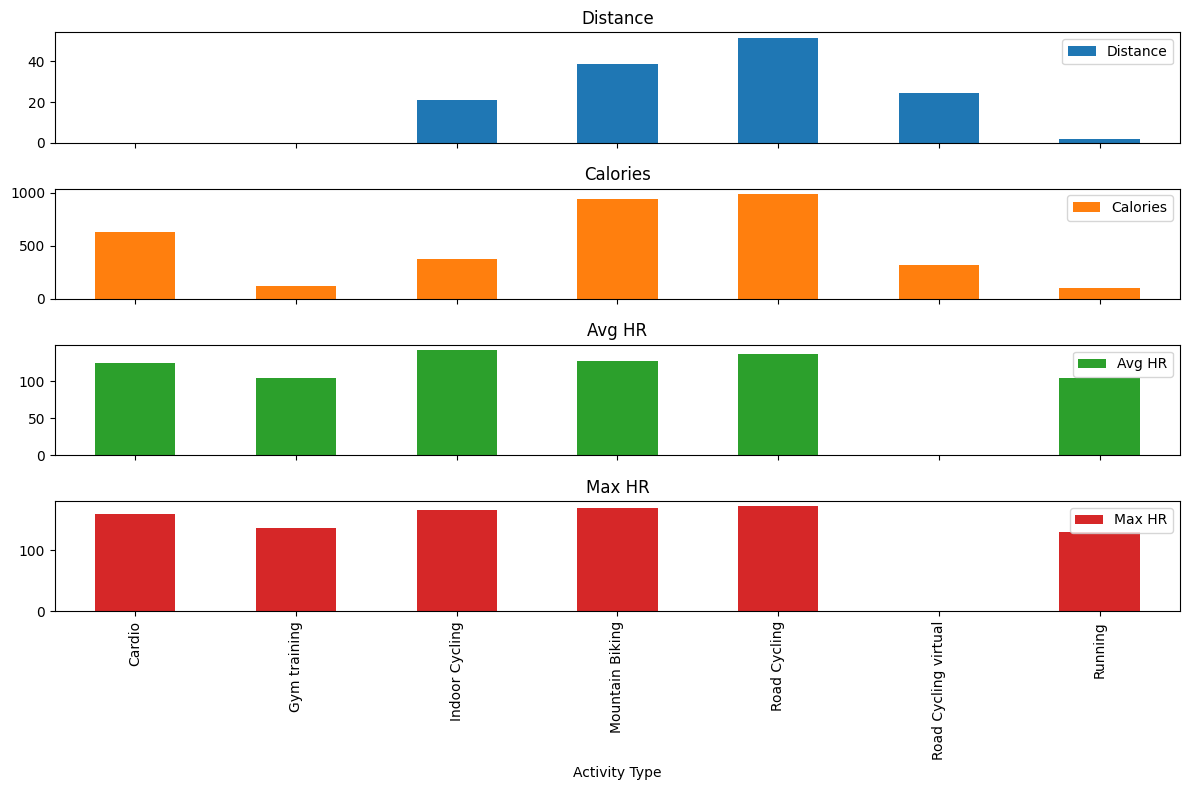

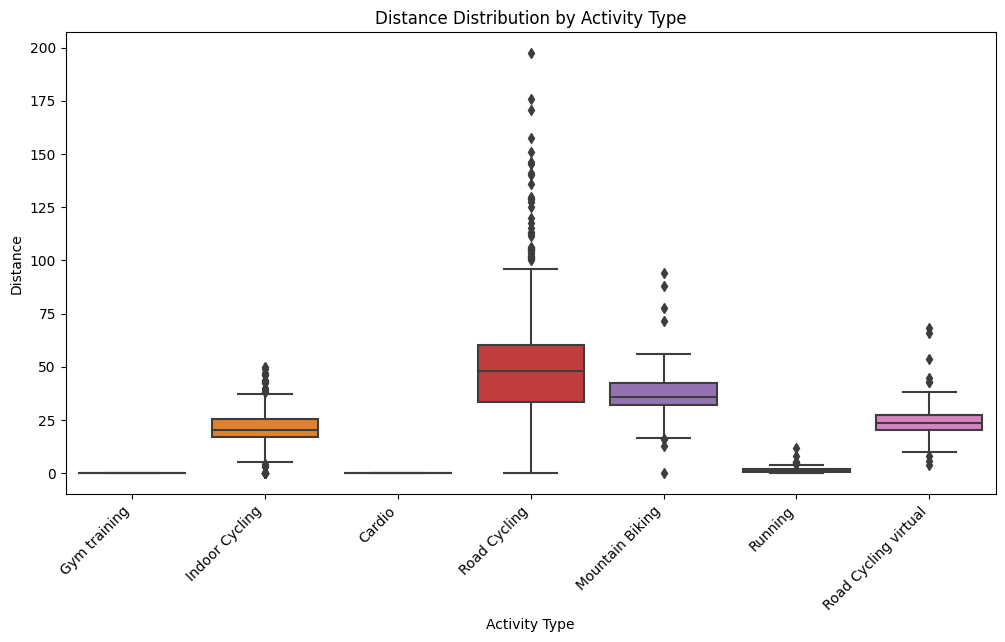

In [17]:
# --- Analysis by Sport (Activity Type) ---

# Example: Average distance and calories for each activity type
activity_avg = data.groupby('Activity Type').agg({'Distance': 'mean', 'Calories': 'mean', 'Avg HR': 'mean', 'Max HR': 'mean'})
print("\nAverage Metrics by Activity Type:\n", activity_avg)

activity_avg.plot(kind='bar', subplots=True, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Example: Boxplots of distance distribution by activity type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Activity Type', y='Distance', data=data)
plt.title('Distance Distribution by Activity Type')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

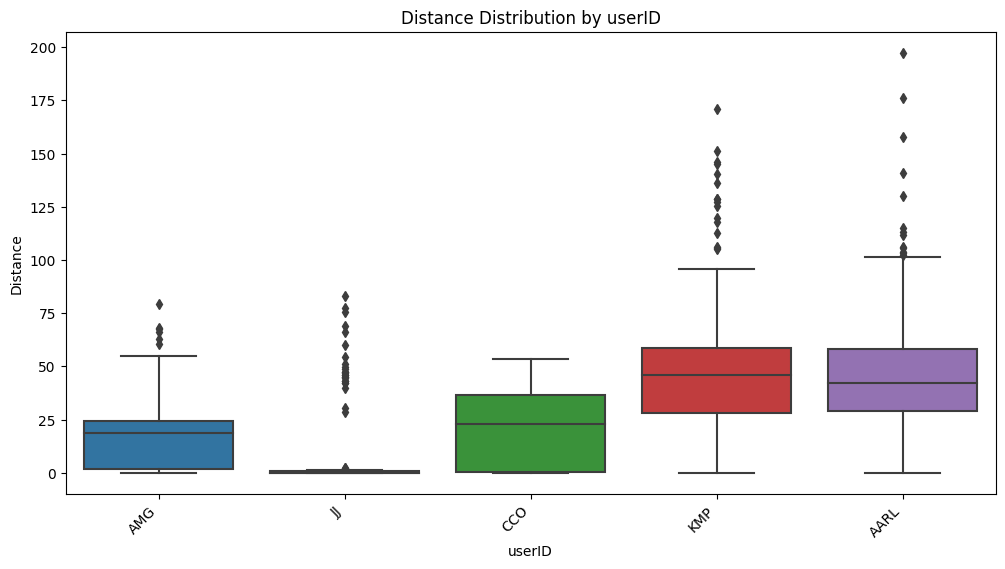

In [18]:
# Boxplots of distance distribution by userID
plt.figure(figsize=(12, 6))
sns.boxplot(x='userID', y='Distance', data=data)
plt.title('Distance Distribution by userID')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

In [28]:
# Data Cleaning and Preparation (as provided in the previous response)
# Convert 'Date' to datetime objects
data['Date'] = pd.to_datetime(data['Date'])

# Handle missing values (example: fill with mean for numeric columns)
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].mean(), inplace=True)

# Clean 'Time' column by replacing '####' with NaN and then imputing with a default value
# Check if 'Time' column exists before cleaning
if 'Time' in data.columns:
    data['Time'] = data['Time'].replace('####', pd.NA)
    data['Time'] = data['Time'].fillna('00:00:00')  # Replace NaN with a default time
else:
    print("Warning: 'Time' column not found in the dataset.")

# Drop duplicates
data.drop_duplicates(inplace=True)


C:\Users\Alejandro.rodriguezl\AppData\Local\Temp\ipykernel_9516\2640251804.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [32]:
# Data Cleaning and Preparation (as provided in the previous response)
# Convert 'Date' to datetime objects
data['Date'] = pd.to_datetime(data['Date'])

# Handle missing values (example: fill with mean for numeric columns)
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].mean(), inplace=True)

# Clean 'Time' column by replacing '####' with NaN and then imputing with a default value
# Check if 'Time' column exists before cleaning
if 'Time' in data.columns:
    data['Time'] = data['Time'].replace('####', pd.NA)
    data['Time'] = data['Time'].fillna('00:00:00')  # Replace NaN with a default time
else:
    print("Warning: 'Time' column not found in the dataset.")

# Drop duplicates
data.drop_duplicates(inplace=True)

# Display the first 5 rows
print(data.head())

# Get information about the columns (data types, missing values)
print(data.info())

# Get descriptive statistics for numeric columns
print(data.describe())



    Activity Type                    Date  Favorite             Title  \
0    Gym training 2022-02-06 19:16:03.993     False            Fuerza   
1    Gym training 2022-02-22 20:36:51.983     False            Fuerza   
2    Gym training 2022-06-15 11:39:56.016     False            Fuerza   
3  Indoor Cycling 2022-09-02 10:03:48.036     False  Ciclismo en sala   
4  Indoor Cycling 2022-09-26 11:09:46.023     False  Ciclismo en sala   

   Distance  Calories                Time  Avg HR  Max HR  Aerobic TE  ...  \
0      0.00     131.0 1899-12-29 00:44:45    99.0   134.0   33.722603  ...   
1      0.00     116.0 1899-12-29 00:32:37   111.0   134.0   33.722603  ...   
2      0.00      90.0 1899-12-29 00:34:18    95.0   121.0   33.722603  ...   
3     20.71     350.0 1899-12-29 00:56:26   146.0   177.0   33.722603  ...   
4     17.77     305.0 1899-12-29 00:46:51   151.0   178.0   33.722603  ...   

    Min Resp   Max Resp Moving Time Elapsed Time  Min Elevation  \
0  15.154246  40.071057  

C:\Users\Alejandro.rodriguezl\AppData\Local\Temp\ipykernel_9516\913644960.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


### 4. K-Means Clustering

In [35]:
# --- Preprocessing for Clustering ---

# Select the features for clustering
cluster_data = data[['Activity Type', 'Distance', 'userID']].copy()

# One-Hot Encode 'Activity Type' and 'userID'
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # handle_unknown='ignore'
encoder_data = pd.DataFrame(
    encoder.fit_transform(cluster_data[['Activity Type', 'userID']]),
    index=cluster_data.index  # Keep the original index
)
encoder_data.columns = encoder.get_feature_names_out(['Activity Type', 'userID'])
cluster_data = cluster_data.drop(['Activity Type', 'userID'], axis=1)
cluster_data = pd.concat([cluster_data, encoder_data], axis=1)

# --- ENSURE NO NaNs BEFORE SCALING AND CLUSTERING ---
print("\ncluster_data info BEFORE handling NaNs:\n")
cluster_data.info()

# Handle any remaining NaNs in cluster_data (if any)
cluster_data.fillna(
    cluster_data.mean(), inplace=True)  # Or use another imputation strategy

print("\ncluster_data info AFTER handling NaNs:\n")
cluster_data.info()

# Scale the numerical features
scaler = StandardScaler()
cluster_data['Distance'] = scaler.fit_transform(cluster_data[['Distance']])


cluster_data info BEFORE handling NaNs:

<class 'pandas.core.frame.DataFrame'>
Index: 1131 entries, 0 to 1132
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Distance                            1131 non-null   float64
 1   Activity Type_Cardio                1131 non-null   float64
 2   Activity Type_Gym training          1131 non-null   float64
 3   Activity Type_Indoor Cycling        1131 non-null   float64
 4   Activity Type_Mountain Biking       1131 non-null   float64
 5   Activity Type_Road Cycling          1131 non-null   float64
 6   Activity Type_Road Cycling virtual  1131 non-null   float64
 7   Activity Type_Running               1131 non-null   float64
 8   userID_AARL                         1131 non-null   float64
 9   userID_AMG                          1131 non-null   float64
 10  userID_CCO                          1131 non-null   float64
 11  userID

In [36]:
# --- K-Means Clustering ---

# Choose the number of clusters (you might need to use methods like the Elbow Method to find the optimal number of clusters)
k = 3  # Example: Let's start with 3 clusters

# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')  # n_init='auto'
cluster_labels = kmeans.fit_predict(cluster_data)

# --- Add Cluster Labels to Original DataFrame ---
data['Cluster'] = pd.Series(cluster_labels, index=cluster_data.index)



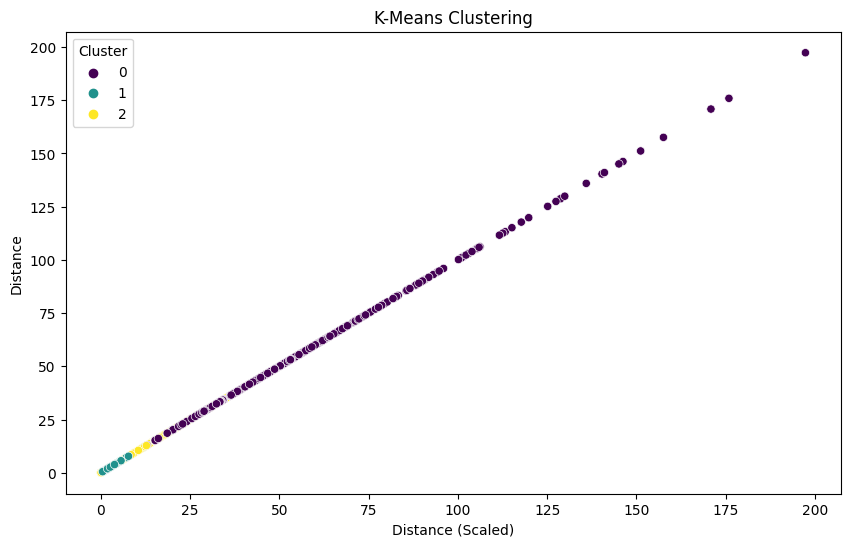


Cluster Centers:
 [[ 7.87826756e-01 -1.38777878e-17  6.24500451e-17  4.44089210e-16
   7.17054264e-02  9.24418605e-01  3.87596899e-03 -1.38777878e-17
   4.68992248e-01  2.13178295e-02  3.10077519e-02  4.84496124e-02
   4.30232558e-01]
 [-1.09644862e+00  3.95256917e-01  1.54150198e-01  3.60822483e-16
   7.90513834e-03  5.13833992e-02  8.32667268e-17  3.91304348e-01
   3.16205534e-02  4.86166008e-01  3.16205534e-02  4.34782609e-01
   1.58102767e-02]
 [-3.56677087e-01  2.22044605e-16  9.02056208e-17  6.10497238e-01
   1.38121547e-02  6.62983425e-02  3.09392265e-01 -2.22044605e-16
   6.35359116e-02  6.79558011e-01  1.93370166e-02  2.22044605e-16
   2.37569061e-01]]


In [40]:
# --- Visualization ---

# Visualize the clusters (example: scatter plot of Distance vs. original 'Distance')
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Distance',  # Use the original 'Distance' (which is scaled)
    y='Distance',  # Plot 'Distance' on both axes
    hue='Cluster',
    data=data,
    palette='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Distance (Scaled)')
plt.ylabel('Distance')  # Update label
plt.show()

# Print cluster centers (optional)
print("\nCluster Centers:\n", kmeans.cluster_centers_)

In [41]:
# --- Cluster Analysis by 'userID' and 'Activity Type' ---

# Crosstabulation: Cluster vs. userID
cluster_user_crosstab = pd.crosstab(data['Cluster'], data['userID'])
print("\nCrosstabulation: Cluster vs. userID\n", cluster_user_crosstab)

# Crosstabulation: Cluster vs. Activity Type
cluster_activity_crosstab = pd.crosstab(data['Cluster'], data['Activity Type'])
print("\nCrosstabulation: Cluster vs. Activity Type\n", cluster_activity_crosstab)




Crosstabulation: Cluster vs. userID
 userID   AARL  AMG  CCO   JJ  KMP
Cluster                          
0         242   11   16   25  222
1           8  123    8  110    4
2          23  246    7    0   86

Crosstabulation: Cluster vs. Activity Type
 Activity Type  Cardio  Gym training  Indoor Cycling  Mountain Biking  \
Cluster                                                                
0                   0             0               0               37   
1                 100            39               0                2   
2                   0             0             221                5   

Activity Type  Road Cycling  Road Cycling virtual  Running  
Cluster                                                     
0                       477                     2        0  
1                        13                     0       99  
2                        24                   112        0  


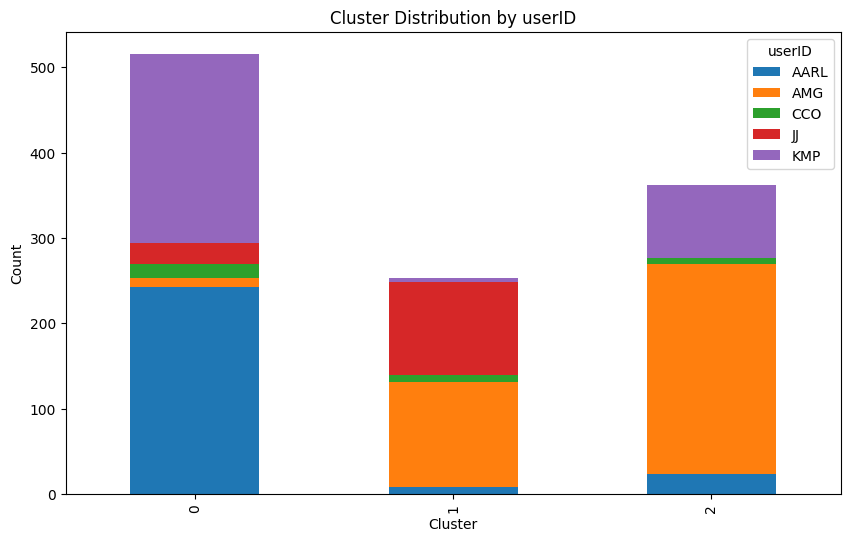

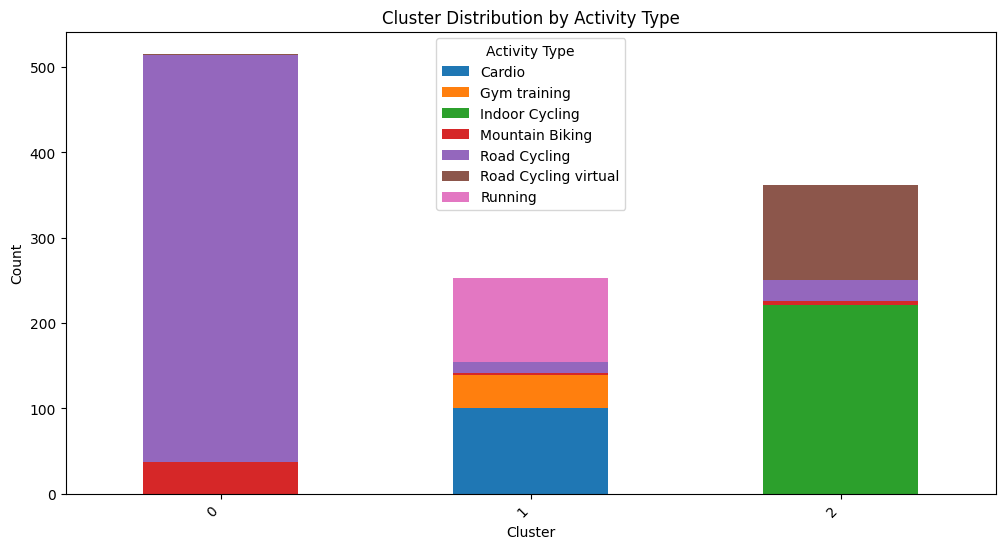

In [42]:
# --- Visualization of Crosstabulations ---

# Stacked bar chart: Cluster distribution by userID
cluster_user_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Cluster Distribution by userID')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Stacked bar chart: Cluster distribution by Activity Type
cluster_activity_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Cluster Distribution by Activity Type')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.show()